In [1]:
from datetime import date
import pandas as pd
import os
import glob
import pycytominer
import matplotlib.pyplot as plt
import seaborn as sns
import umap

/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packag

In [3]:
# load custom collection of functions
import sys
sys.path.append('/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/')
import utility_functions as UTIL

In [4]:
parent_directory = "/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/"

input_path = parent_directory + "results/"

annot_path = parent_directory  + "annotations/"

output_path = parent_directory + "revision_results/"

figure_path = parent_directory + "revision_figures/"


# UMAP 

Settings:

n_neighbors = 30

min_dist = 0.1

In [5]:
def draw_umap(data,
              features,
              metadata,
              cell_type, 
              n_neighbors=15, 
              min_dist=0.1, 
              n_components=2, 
              metric='euclidean',
              title='',
              filename = ''):
    
    # function is a UMAP
    axis_1 = "UMAP_Axis_1"
    axis_2 = "UMAP_Axis_2"
    
    # plot params
    marker_color = ["lightgray", "purple"]
    marker_edgecolor = "none"
    marker_size = 15
    marker_alpha = 0.6
    
    fit = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    
    u = fit.fit_transform(features);

    u_dataframe = pd.DataFrame(data = u,
                               columns = [axis_1, 
                                          axis_2])

    # Get EOS annotation back
    u_dataframe_annot = pd.merge(data.loc[:, metadata], 
                                  u_dataframe, 
                                  left_index = True, 
                                  right_index = True)

    fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 15))
    fig.suptitle(title, fontsize=18)
    
    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_' + cell_type + '_inactive',
        palette = ["lightgray", "navy"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[0, 0]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_' + cell_type + '_Toxic',
        palette = ["lightgray", "purple"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[0, 1]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_tubulin',
        palette = ["lightgray", "darkgreen"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[0, 2]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_DMSO',
        palette = marker_color,
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[1, 0]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_Nocodazole',
        palette = marker_color,
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[1, 1]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_Tetrandrine',
        palette = marker_color,
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[1, 2]
    )
    
    plt.savefig(filename)  

# Load data

In [6]:
# data_U2OS_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_U2OS_norm.csv")
file_U2OS_type = '/*[0-9]_' + 'FMP_U2OS_norm.csv'
files_U2OS = glob.glob(input_path + file_U2OS_type)

### gets latest file
max_file_U2OS = max(files_U2OS, key=os.path.getctime)

### load file
data_U2OS_Norm = pd.read_csv(max_file_U2OS)
data_U2OS_Norm.shape

(10629, 2984)

In [7]:
# data_HepG2_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_HepG2_norm.csv")
file_HepG2_type = '/*[0-9]_' + 'FMP_HepG2_norm.csv'
files_HepG2 = glob.glob(input_path + file_HepG2_type)

### gets latest file
max_file_HepG2 = max(files_HepG2, key=os.path.getctime)

### load file
data_HepG2_Norm = pd.read_csv(max_file_HepG2)
data_HepG2_Norm.shape

(10697, 2984)

# Load reduced features

In [13]:
# data_HepG2_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_HepG2_norm.csv")
reduced_features_type = '/*[0-9]_' + "FMP_U2OS_HepG2_Features.csv"
reduced_features = glob.glob(output_path + reduced_features_type)

### gets latest file
max_reduced_features = max(reduced_features, key=os.path.getctime)

### load file
data_reduced_features= pd.read_csv(max_reduced_features)

In [18]:
data_reduced_features = data_reduced_features.drop(index=631)

# Feature reduction

In [19]:
data_U2OS_reduced = data_U2OS_Norm[data_reduced_features['0']].copy()
data_HepG2_reduced = data_HepG2_Norm[data_reduced_features['0']].copy()

In [20]:
# Compute consensus
## gets feature vector
Features_data_U2OS_reduced = UTIL.get_feature_vector(data_U2OS_reduced)

# Compute consensus
data_U2OS_reduced_Median = pycytominer.consensus(
        profiles = data_U2OS_reduced, # A file or pandas DataFrame of profile data
        replicate_columns = ["Metadata_EOS", "Metadata_Plate", "Metadata_Concentration", "Metadata_Partner"], # Metadata columns indicating which replicates to collapse, defaults to [“Metadata_Plate”, “Metadata_Well”]
        operation = "median", # (str) – The method used to form consensus profiles, defaults to “median”
        features = Features_data_U2OS_reduced, # (str, list) – The features to collapse, defaults to “infer”
)

In [21]:
# Compute consensus
## gets feature vector
Features_data_HepG2_reduced = UTIL.get_feature_vector(data_HepG2_reduced)

# Compute consensus
data_HepG2_reduced_Median = pycytominer.consensus(
        profiles = data_HepG2_reduced, # A file or pandas DataFrame of profile data
        replicate_columns = ["Metadata_EOS", "Metadata_Plate", "Metadata_Concentration", "Metadata_Partner"], # Metadata columns indicating which replicates to collapse, defaults to [“Metadata_Plate”, “Metadata_Well”]
        operation = "median", # (str) – The method used to form consensus profiles, defaults to “median”
        features = Features_data_HepG2_reduced, # (str, list) – The features to collapse, defaults to “infer”
)

In [22]:
# Combine datasets
data_U2OS_reduced_Median["Metadata_cell_line"] = "U2OS"
data_HepG2_reduced_Median["Metadata_cell_line"] = "HepG2"

data_U2OS_HepG2_reduced_median = pd.concat([data_U2OS_reduced_Median, data_HepG2_reduced_Median])

# Basic UMAP with Metadata_cell_line as label

In [23]:
def draw_umap_cellLine(data,
              features,
              metadata,
              n_neighbors=15, 
              min_dist=0.1, 
              n_components=2, 
              metric='euclidean',
              title='',
              filename = ''):
    
    # function is a UMAP
    axis_1 = "UMAP_Axis_1"
    axis_2 = "UMAP_Axis_2"
    
    # plot params
    marker_edgecolor = "none"
    marker_size = 15
    marker_alpha = 0.6
    
    fit = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    
    u = fit.fit_transform(features);

    u_dataframe = pd.DataFrame(data = u,
                               columns = [axis_1, 
                                          axis_2])

    # Get EOS annotation back
    u_dataframe_annot = pd.merge(data.loc[:, metadata], 
                                  u_dataframe, 
                                  left_index = True, 
                                  right_index = True)
    plt.figure(figsize=(15, 15))  # Width = 10 inches, Height = 6 inches

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = "Metadata_cell_line",
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha 
    )

    # plt.savefig(filename)  

In [24]:
# Data without metadata columns
data_U2OS_HepG2_reduced_median = data_U2OS_HepG2_reduced_median.reset_index(drop = True)
data_U2OS_HepG2_reduced_median_Features = UTIL.get_feature_vector(data_U2OS_HepG2_reduced_median)
data_U2OS_HepG2_reduced_median_Meta_Features = list(set(data_U2OS_HepG2_reduced_median.columns) - set(data_U2OS_HepG2_reduced_median_Features))

data_U2OS_HepG2_reduced_median_x = data_U2OS_HepG2_reduced_median.loc[:, data_U2OS_HepG2_reduced_median_Features]

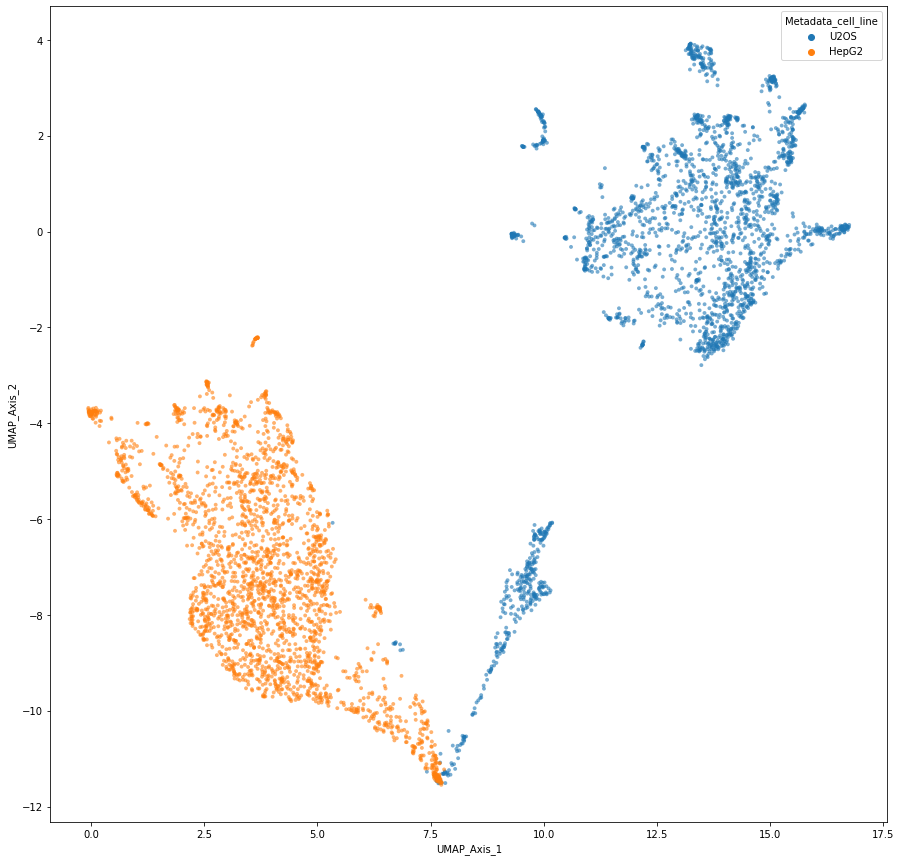

In [25]:
draw_umap_cellLine(data_U2OS_HepG2_reduced_median, 
                   data_U2OS_HepG2_reduced_median_x,
                   data_U2OS_HepG2_reduced_median_Meta_Features)

# Perform UMAP with only filtered compounds

In [26]:
file_U2OS_Median_type = '/*[0-9]_' + 'FMP_U2OS_norm_reduced_filtered_median.csv'
files_U2OS_Median = glob.glob(input_path + file_U2OS_Median_type)

### gets latest file
max_file_U2OS_Median = max(files_U2OS_Median, key=os.path.getctime)

### load file
data_U2OS_filtered = pd.read_csv(max_file_U2OS_Median)
data_U2OS_filtered.shape

(1345, 742)

In [27]:
file_HepG2_Median_type = '/*[0-9]_' + 'FMP_HepG2_norm_reduced_filtered_median.csv'
files_HepG2_Median = glob.glob(input_path + file_HepG2_Median_type)

### gets latest file
max_file_HepG2_Median = max(files_HepG2_Median, key=os.path.getctime)

### load file
data_HepG2_filtered = pd.read_csv(max_file_HepG2_Median)
data_HepG2_filtered.shape

(801, 658)

In [28]:
data_U2OS_filtered.head()

,Metadata_EOS,Metadata_Plate,Metadata_Concentration,Metadata_Partner,Nuc_AreaShape_BoundingBoxArea,Nuc_AreaShape_BoundingBoxMinimum_X,Nuc_AreaShape_Compactness,Nuc_AreaShape_Extent,Nuc_AreaShape_FormFactor,Nuc_AreaShape_MinFeretDiameter,...,Cyto_Texture_InverseDifferenceMoment_DNA_10_01_256,Cyto_Texture_InverseDifferenceMoment_DNA_10_03_256,Cyto_Texture_InverseDifferenceMoment_DNA_3_00_256,Cyto_Texture_InverseDifferenceMoment_DNA_3_01_256,Cyto_Texture_InverseDifferenceMoment_DNA_3_03_256,Cyto_Texture_InverseDifferenceMoment_DNA_5_00_256,Cyto_Texture_InverseDifferenceMoment_ER_10_01_256,Cyto_Texture_InverseDifferenceMoment_ER_5_03_256,Cyto_Texture_InverseDifferenceMoment_Mito_3_02_256,Cyto_Texture_SumAverage_DNA_3_00_256
0,EOS100004,B1001,10,Bioactives,1.440663,0.137165,0.032665,0.383985,-0.031743,0.945128,...,0.454941,0.701808,-0.197835,0.067684,0.435924,-0.215480,-5.825556,-5.148229,0.700623,-0.305906
1,EOS100005,B1001,10,Bioactives,-1.117691,-0.654842,-1.214050,0.785816,1.230209,-0.094179,...,0.380581,0.901834,-0.184844,-0.156313,-0.027029,-0.161276,-6.895279,-8.010751,0.656034,-0.633295
2,EOS100006,B1001,10,Bioactives,0.516064,0.422545,-0.608222,0.431334,0.613920,0.531860,...,-0.148488,-0.018259,-0.140854,-0.180894,0.449831,-0.088635,-6.155957,-7.204564,0.324453,0.176756
3,EOS100007,B1001,10,Bioactives,0.479638,-1.041602,0.120032,-0.773869,-0.119307,0.332956,...,1.164191,2.095741,1.275829,0.761223,1.731913,1.017425,-5.340155,-5.854969,0.648607,-1.668410
4,EOS100009,B1001,10,Bioactives,-0.825903,-1.989842,2.551672,-1.588957,-2.521092,-0.492455,...,2.560441,1.898461,2.977098,1.746517,2.424811,1.402149,-4.561538,-4.766277,-0.832318,-2.575370


In [61]:
# Find intersection based on the 'ID' column
intersection = pd.merge(data_U2OS_filtered, data_HepG2_filtered, on='Metadata_EOS')

In [67]:
data_filtered = data_U2OS_HepG2_reduced_median[data_U2OS_HepG2_reduced_median['Metadata_EOS'].isin(intersection['Metadata_EOS'])]

In [70]:
# Data without metadata columns
data_filtered_reset = data_filtered.reset_index(drop = True)
data_filtered_reset_Features = UTIL.get_feature_vector(data_filtered_reset)
data_filtered_reset_Meta_Features = list(set(data_filtered_reset.columns) - set(data_filtered_reset_Features))

data_filtered_reset_x = data_filtered_reset.loc[:, data_filtered_reset_Features]

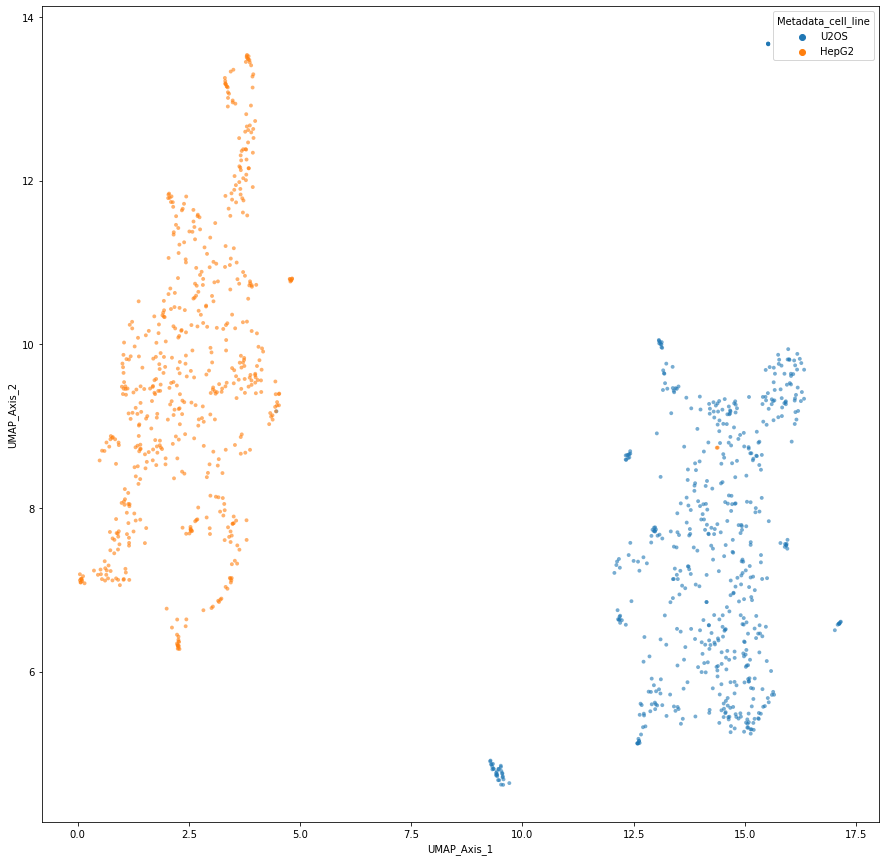

In [71]:
draw_umap_cellLine(data_filtered_reset, 
                   data_filtered_reset_x,
                   data_filtered_reset_Meta_Features)

# Load and viz of further annotations

In [72]:
pairing_type = '/*[0-9]_' + 'EOS_Pairing_Compouds.csv'
files_file_pairing = glob.glob(output_path + pairing_type)

### gets latest file
max_file_pairing = max(files_file_pairing, key=os.path.getctime)

### load file
data_file_pairing = pd.read_csv(max_file_pairing)
data_file_pairing.shape

(129, 2)

In [77]:
for_viz = data_filtered_reset.copy()

In [78]:
for_viz['Metadata_Nocodazole'] = for_viz['Metadata_EOS'].str.contains('Nocodazole', case=False, na=False)
for_viz['Metadata_Tetrandrine'] = for_viz['Metadata_EOS'].str.contains('Tetrandrine', case=False, na=False)

In [79]:
for_viz

,Metadata_EOS,Metadata_Plate,Metadata_Concentration,Metadata_Partner,Nuc_AreaShape_BoundingBoxMinimum_X,Nuc_AreaShape_BoundingBoxMinimum_Y,Nuc_AreaShape_Compactness,Nuc_AreaShape_Extent,Nuc_AreaShape_FormFactor,Nuc_AreaShape_MinorAxisLength,...,Cyto_Texture_InverseDifferenceMoment_DNA_10_01_256,Cyto_Texture_InverseDifferenceMoment_DNA_10_03_256,Cyto_Texture_InverseDifferenceMoment_DNA_3_01_256,Cyto_Texture_InverseDifferenceMoment_DNA_3_03_256,Cyto_Texture_InverseDifferenceMoment_ER_10_01_256,Cyto_Texture_InverseDifferenceMoment_ER_5_03_256,Cyto_Texture_SumAverage_DNA_3_00_256,Metadata_cell_line,Metadata_Nocodazole,Metadata_Tetrandrine
0,EOS100021,B1001,10,Bioactives,0.717440,-0.806456,2.921880,-2.266367,-2.855476,-1.274418,...,-0.001944,-0.411083,0.154634,0.326567,-0.910729,-2.052630,-0.583570,U2OS,False,False
1,EOS100022,B1001,10,Bioactives,-0.078073,0.717257,5.195742,-4.076258,-4.972976,16.333356,...,1.138184,1.640801,3.828706,3.519737,-0.441085,-0.236357,-2.883936,U2OS,False,False
2,EOS100024,B1001,10,Bioactives,-1.676969,-1.227769,17.996958,-12.155334,-16.098415,14.117493,...,0.015265,0.414499,2.086017,2.210483,-14.157864,-15.013875,-1.670075,U2OS,False,False
3,EOS100028,B1001,10,Bioactives,-0.112433,-0.601732,2.862146,-3.368555,-2.785470,0.876475,...,-1.253287,-1.283701,0.682071,0.996932,-3.744825,-4.079538,-1.042584,U2OS,False,False
4,EOS100037,B1001,10,Bioactives,-0.295171,0.049765,-4.910549,3.562463,5.083023,0.906038,...,0.113486,0.820738,0.155027,0.485397,-2.509345,-2.937740,-0.767106,U2OS,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1135,Tetrandrine,B1003,5,Bioactives,-1.089645,1.240101,-4.132877,3.438206,4.307512,-9.678634,...,3.611486,2.740408,2.489372,2.141987,-0.814722,-1.456086,-2.908849,HepG2,False,True
1136,Tetrandrine,B1004,5,Bioactives,-0.445053,0.228690,-5.732752,3.703906,5.964143,-11.720930,...,2.791651,2.513831,2.467154,2.229374,-0.479319,-2.140949,-2.703106,HepG2,False,True
1137,Tetrandrine,B1005,5,Bioactives,-0.607861,0.539593,-4.422828,3.604339,4.536630,-11.159077,...,3.743182,2.195102,2.987459,3.090165,-1.224180,-1.846781,-3.694147,HepG2,False,True
1138,Tetrandrine,B1006,5,Bioactives,-0.271582,0.621537,-4.802364,3.723135,4.997594,-8.652753,...,1.825594,2.142654,0.926052,0.934958,-1.143984,-1.770041,-1.494233,HepG2,False,True


# Load annotations

In [80]:
annotation_compounds = pd.read_csv(annot_path + "pd_export_04_2022_2464_compounds_standardized.csv")
annotation_compounds.columns = annotation_compounds.columns.str.replace(' ', '_')
annotation_compounds = annotation_compounds.add_prefix('Metadata_')
id_file = pd.read_csv(annot_path + "2024-08-02_EOS_pdid.csv")
annotation_tubulin = pd.read_csv(annot_path + "2024-08-02_Tubulin.csv")
annotation_tubulin.shape

(2464, 2)

In [81]:
# get EUOS number 
annotation_compounds = pd.merge(annotation_compounds,
                     annotation_tubulin,
                     on = ["Metadata_pdid"],
                     how = "left",
                     indicator = False)

In [82]:
# get EUOS number 
annotation_compounds_2 = pd.merge(annotation_compounds,
                     id_file,
                     on = ["Metadata_pdid"],
                     how = "left",
                     indicator = False)

In [83]:
# get EUOS number 
annotation_compounds_2 = pd.merge(annotation_compounds,
                     id_file,
                     on = ["Metadata_pdid"],
                     how = "left",
                     indicator = False)

In [84]:
for_viz_annot = pd.merge(for_viz,
                         annotation_compounds_2,
                         how = 'left',
                         on=['Metadata_EOS'])

In [85]:
for_viz_annot['pairing'] = for_viz_annot['Metadata_EOS'].isin(data_file_pairing['Metadata_EOS'])
for_viz_annot = for_viz_annot.rename(columns={'pairing': 'Metadata_pairing'})

In [86]:
def draw_umap(data,
              features,
              metadata,
              n_neighbors=15, 
              min_dist=0.1, 
              n_components=2, 
              metric='euclidean',
              title='',
              filename = ''):
    
    # function is a UMAP
    axis_1 = "UMAP_Axis_1"
    axis_2 = "UMAP_Axis_2"
    
    # plot params
    marker_color = ["lightgray", "purple"]
    marker_edgecolor = "none"
    marker_size = 15
    marker_alpha = 0.6
    
    fit = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    
    u = fit.fit_transform(features)

    u_dataframe = pd.DataFrame(data = u,
                               columns = [axis_1, 
                                          axis_2])

    # Get EOS annotation back
    u_dataframe_annot = pd.merge(data.loc[:, metadata], 
                                  u_dataframe, 
                                  left_index = True, 
                                  right_index = True)
    
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 15))
    fig.suptitle(title, fontsize=18)

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_pairing',
        palette = ["lightgray", "darkgreen"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        zorder=1,
        ax=axs[0,0]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_cell_line',
        palette = ["lightgray", "darkgreen"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        zorder=1,
        ax=axs[0,1]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_Tetrandrine',
        palette = ["lightgray", "darkgreen"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        zorder=1,
        ax=axs[1,0]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_Nocodazole',
        palette = ["lightgray", "darkgreen"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        zorder=1,
        ax=axs[1,1]
    )


In [87]:
# Data without metadata columns
for_viz_annot_reset = for_viz_annot.reset_index(drop = True)
for_viz_annot_reset_Features = UTIL.get_feature_vector(for_viz_annot_reset)
for_viz_annot_reset_Meta_Features = list(set(for_viz_annot_reset.columns) - set(for_viz_annot_reset_Features))
    
for_viz_annot_x = for_viz_annot_reset.loc[:, for_viz_annot_reset_Features ]

<ipython-input-86-527ba133777f>:82: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(


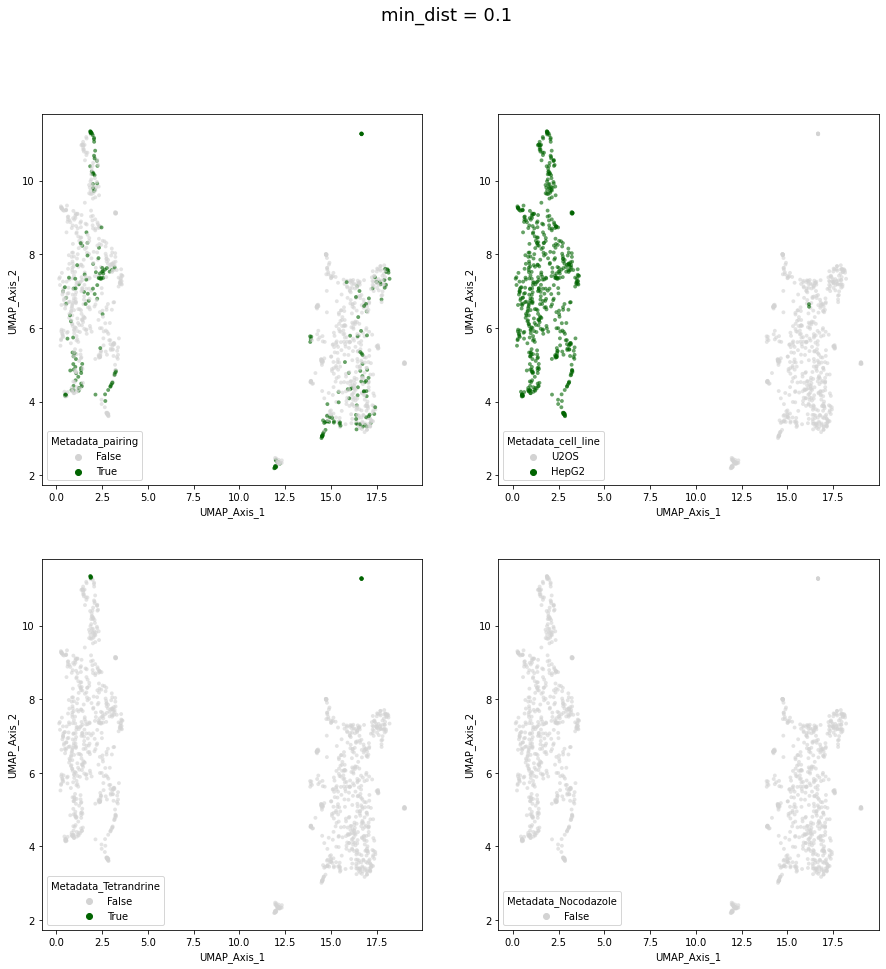

In [88]:
filename_for_viz_annot_x= figure_path + str(date.today()) + "_CellLineComp.pdf"

draw_umap(data = for_viz_annot_reset,
          features = for_viz_annot_x,
          metadata = for_viz_annot_reset_Meta_Features,
          n_neighbors=15,
          min_dist=0.1,
          title='min_dist = {}'.format(0.1),
          filename = filename_for_viz_annot_x)